# 05 — Train E1 SimpleCNN (Gate 3)
- **Model:** PROJECT_SPEC §8 E1, `src/models/simple_cnn.py`. Settings: `configs/config.yaml` → `experiments.E1` and `training` (D009, D010, D018).
- **Data:** the frozen grouped split (D016) through `src/dataset.py`; training augmentation D011; the validation set is used for checkpoint selection and early stopping.
- **The test set is not loaded in this notebook.** E1–E3 are evaluated on test once, in a separate final-evaluation notebook, after all models are selected (CONSTITUTION C3).
- **Outputs (Drive):** `03_Checkpoints/E1/E1_best.pt`, `E1_last.pt`; `04_Results/experiments/E1/E1_history.csv`, `E1_curves.png`, `E1_val_per_class_metrics.csv`, `E1_val_confusion_matrix.png`, `E1_training_summary.json`.
- **If Colab disconnects:** reconnect and Run all; training resumes from `E1_last.pt`. To start over, rename or delete `03_Checkpoints/E1/` first.
- **Runtime:** GPU (T4).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/KNV-DSEB/realwaste-classification.git"
REPO_DIR = Path("/content/realwaste-classification")

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
else:
    subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only"], check=True)
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

print(subprocess.run(["git", "-C", str(REPO_DIR), "log", "-1", "--oneline"],
                     capture_output=True, text=True).stdout)

c785cb4 Share 40-epoch cap for E1/E2 and allow extending a capped run (D019)



In [3]:
import json
from datetime import datetime

import matplotlib.pyplot as plt
import torch
from torch import nn

from src.dataset import get_dataloaders, load_class_mapping, load_frozen_split
from src.evaluate import classification_metrics, per_class_metrics, plot_confusion_matrix, predict
from src.models.simple_cnn import SimpleCNN
from src.train import build_optimizer, build_scheduler, fit, plot_history
from src.utils import count_parameters, environment_info, get_paths, load_config, set_seed

EXPERIMENT_ID = "E1"
cfg = load_config(REPO_DIR / "configs" / "config.yaml")
exp_cfg = cfg["experiments"][EXPERIMENT_ID]
paths = get_paths(cfg)
CHECKPOINT_DIR = paths.checkpoint_dir / EXPERIMENT_ID
RESULT_DIR = paths.result_dir / "experiments" / EXPERIMENT_ID
RESULT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type != "cuda":
    print("WARNING: no GPU. Runtime -> Change runtime type -> T4 GPU, then Run all.")
amp = exp_cfg["amp"] and device.type == "cuda"
env = environment_info()
print(json.dumps(env, indent=2))
print("device:", device, "| AMP:", amp)

{
  "python": "3.13.15",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
  "torch": "2.11.0+cu130",
  "torchvision": "0.26.0+cu130",
  "numpy": "2.1.3",
  "pandas": "2.2.3",
  "scikit_learn": "1.6.1",
  "pillow": "11.3.0",
  "cuda_available": true,
  "gpu": "Tesla T4",
  "cudnn": 92700,
  "git_commit": "c785cb4ffc739fa16fda743b7e89c7f5895b21e3",
  "git_dirty": false
}
device: cuda | AMP: True


In [4]:
split_df = load_frozen_split(cfg)  # SHA256-verified frozen grouped split (D016)
class_names = load_class_mapping(cfg)["class_name"].tolist()
num_classes = len(class_names)
train_loader, val_loader = get_dataloaders(cfg, split_df=split_df)  # train + validation only
print({s: int(n) for s, n in split_df["split"].value_counts().items()})
print("train batches:", len(train_loader), "| val batches:", len(val_loader))

{'train': 3326, 'val': 719, 'test': 707}
train batches: 104 | val batches: 23


In [5]:
set_seed(cfg["project"]["seed"])  # identical initial weights on every fresh run
model = SimpleCNN(num_classes, dropout=exp_cfg["dropout"]).to(device)
optimizer = build_optimizer(model.parameters(), exp_cfg)
scheduler = build_scheduler(optimizer, exp_cfg)
criterion = nn.CrossEntropyLoss()  # unweighted (D009)
parameter_count = count_parameters(model)
print(model)
print(f"Trainable parameters: {parameter_count:,}")

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=1)
  (classifier): Sequential(
    (0): Flatten(star

In [6]:
run_info = {
    "experiment_id": EXPERIMENT_ID,
    "run_id": f"{EXPERIMENT_ID}_{datetime.now():%Y%m%d-%H%M%S}",
    "model_name": exp_cfg["model_name"],
    "model_kwargs": {"num_classes": num_classes, "dropout": exp_cfg["dropout"]},
    "class_names": class_names,
    "split_sha256": cfg["split"]["split_sha256"],
    "git_commit": env["git_commit"],
}
result = fit(
    model, train_loader, val_loader,
    optimizer=optimizer, scheduler=scheduler, criterion=criterion, device=device, amp=amp,
    num_classes=num_classes,
    max_epochs=cfg["training"]["epochs_simple"],
    patience=cfg["training"]["early_stopping_patience"],
    checkpoint_dir=CHECKPOINT_DIR,
    experiment_id=EXPERIMENT_ID,
    history_path=RESULT_DIR / f"{EXPERIMENT_ID}_history.csv",
    run_info=run_info,
)

Extending E1 (E1_20261003-145155) at epoch 31, max 40
epoch  31 | train loss 1.0093 acc 0.6335 | val loss 1.0286 acc 0.6481 macro-F1 0.6418 | lr 1.25e-04 | 41s
epoch  32 | train loss 0.9639 acc 0.6416 | val loss 1.0540 acc 0.6453 macro-F1 0.6342 | lr 6.25e-05 | 44s
epoch  33 | train loss 0.9622 acc 0.6416 | val loss 1.0392 acc 0.6565 macro-F1 0.6499 | lr 6.25e-05 | 41s  *best*
epoch  34 | train loss 0.9807 acc 0.6377 | val loss 1.0249 acc 0.6453 macro-F1 0.6358 | lr 6.25e-05 | 42s
epoch  35 | train loss 0.9850 acc 0.6404 | val loss 1.0183 acc 0.6467 macro-F1 0.6373 | lr 6.25e-05 | 40s
epoch  36 | train loss 0.9730 acc 0.6449 | val loss 1.0106 acc 0.6495 macro-F1 0.6415 | lr 6.25e-05 | 40s
epoch  37 | train loss 0.9723 acc 0.6359 | val loss 1.0229 acc 0.6398 macro-F1 0.6314 | lr 3.13e-05 | 41s
epoch  38 | train loss 0.9688 acc 0.6422 | val loss 1.0203 acc 0.6453 macro-F1 0.6351 | lr 3.13e-05 | 41s
Early stopping: no validation macro-F1 improvement for 5 epochs.
Best epoch 33: validation

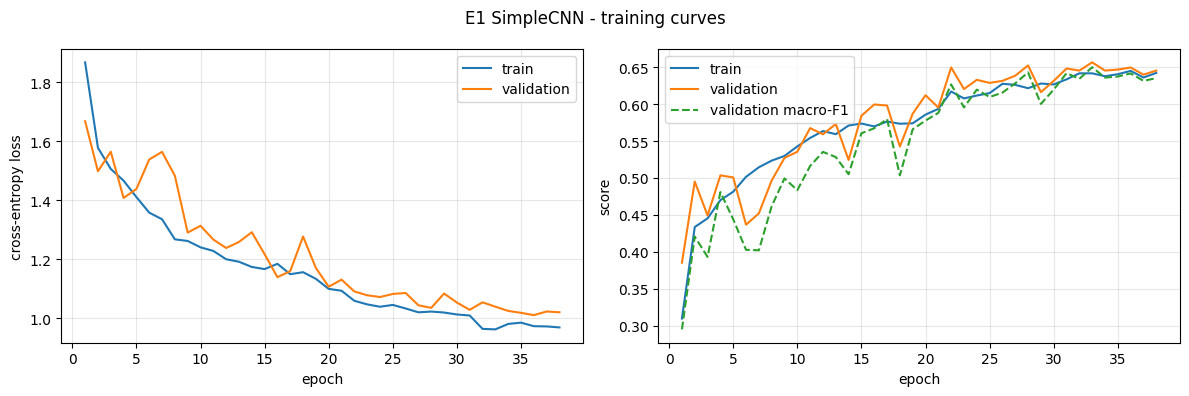

In [7]:
history = result.history
fig = plot_history(history, f"{EXPERIMENT_ID} SimpleCNN - training curves")
fig.savefig(RESULT_DIR / f"{EXPERIMENT_ID}_curves.png", dpi=150, bbox_inches="tight")
plt.show()

Best checkpoint: epoch 33
Validation: {'accuracy': 0.6565, 'macro_precision': 0.7058, 'macro_recall': 0.6357, 'macro_f1': 0.6499} | macro-F1 recorded during training: 0.6499
 class_index          class_name  support  precision  recall     f1
           0           Cardboard       70     0.8727  0.6857 0.7680
           1       Food Organics       60     0.7619  0.8000 0.7805
           2               Glass       60     0.6000  0.5500 0.5739
           3               Metal      120     0.7660  0.6000 0.6729
           4 Miscellaneous Trash       80     0.5581  0.3000 0.3902
           5               Paper       70     0.8305  0.7000 0.7597
           6             Plastic      140     0.4659  0.8286 0.5964
           7       Textile Trash       49     0.6364  0.2857 0.3944
           8          Vegetation       70     0.8608  0.9714 0.9128


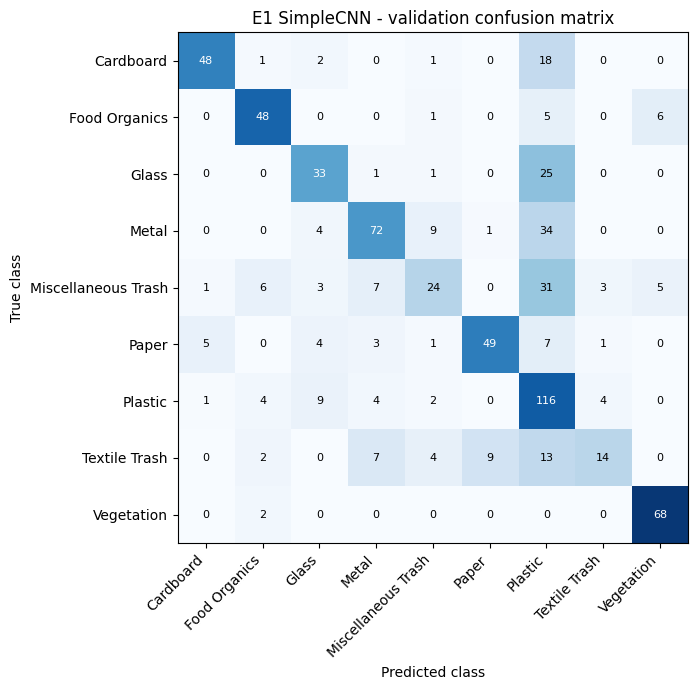

In [8]:
# Validation diagnostics of the selected (best) checkpoint. The test set stays untouched.
best = torch.load(result.best_path, map_location=device)
model.load_state_dict(best["model"])
val = predict(model, val_loader, device, criterion, amp)
val_metrics = classification_metrics(val.y_true, val.y_pred, num_classes)
print("Best checkpoint: epoch", best["epoch"])
print("Validation:", {k: round(v, 4) for k, v in val_metrics.items()},
      "| macro-F1 recorded during training:", round(best["val_metrics"]["macro_f1"], 4))

val_per_class = per_class_metrics(val.y_true, val.y_pred, class_names)
val_per_class.to_csv(RESULT_DIR / f"{EXPERIMENT_ID}_val_per_class_metrics.csv", index=False)
print(val_per_class.to_string(index=False))

fig = plot_confusion_matrix(val.y_true, val.y_pred, class_names,
                            f"{EXPERIMENT_ID} SimpleCNN - validation confusion matrix")
fig.savefig(RESULT_DIR / f"{EXPERIMENT_ID}_val_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Run record (EXPERIMENT_PROTOCOL "Training records"; PROJECT_CONTROL_CENTER "Experiment Runs").
summary = {
    **result.run_info,
    "seed": cfg["project"]["seed"],
    "batch_size": cfg["training"]["batch_size"],
    "optimizer": exp_cfg["optimizer"],
    "learning_rate": exp_cfg["lr"],
    "weight_decay": exp_cfg["weight_decay"],
    "scheduler": exp_cfg["scheduler"],
    "epochs_planned": cfg["training"]["epochs_simple"],
    "epochs_completed": int(history["epoch"].max()),
    "stopped_early": result.stopped_early,
    "early_stopping": f"{cfg['training']['early_stopping_monitor']}, patience {cfg['training']['early_stopping_patience']}",
    "augmentation": "D011 training profile",
    "class_weighting": cfg["data"]["class_weighting"],
    "amp": amp,
    "best_epoch": result.best_epoch,
    "selection_metric": cfg["training"]["selection_metric"],
    "best_val_macro_f1": result.best_val_macro_f1,
    "best_val_metrics": val_metrics,
    "parameter_count": parameter_count,
    "training_time_minutes": round(float(history["seconds"].sum()) / 60, 1),
    "checkpoint_path": str(result.best_path),
    "environment": env,
    "config_snapshot": cfg,
    "notes": "",
}
with open(RESULT_DIR / f"{EXPERIMENT_ID}_training_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps({k: v for k, v in summary.items() if k not in ("environment", "config_snapshot", "class_names")}, indent=2))

{
  "experiment_id": "E1",
  "run_id": "E1_20261003-145155",
  "model_name": "SimpleCNN",
  "model_kwargs": {
    "num_classes": 9,
    "dropout": 0.3
  },
  "split_sha256": "65dc85e83acee56f5db0a0f3b9b5f08c84cf71d3d35c76f69c5213d4a33b3d3d",
  "git_commit": "df98d0a51785753cf2375c9ef64b192c01d2ad57",
  "seed": 42,
  "batch_size": 32,
  "optimizer": "adamw",
  "learning_rate": 0.001,
  "weight_decay": 0.0001,
  "scheduler": "reduce_on_plateau",
  "epochs_planned": 40,
  "epochs_completed": 38,
  "stopped_early": true,
  "early_stopping": "val_macro_f1, patience 5",
  "augmentation": "D011 training profile",
  "class_weighting": "none",
  "amp": true,
  "best_epoch": 33,
  "selection_metric": "val_macro_f1",
  "best_val_macro_f1": 0.64986,
  "best_val_metrics": {
    "accuracy": 0.6564673157162726,
    "macro_precision": 0.7058026749722578,
    "macro_recall": 0.6357142857142857,
    "macro_f1": 0.6498611969834133
  },
  "parameter_count": 111145,
  "training_time_minutes": 39.0,
  "chec

## Next
1. Save this notebook with outputs to GitHub (File → Save a copy in GitHub) and send the summary printed above.
2. Copy the run into `PROJECT_CONTROL_CENTER.xlsx` → *Experiment Runs* and `experiments/E1_SimpleCNN/README.md`.
3. Do not evaluate on the test set here; that happens once for E1–E3 in the final-evaluation notebook.